# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Albert Sanggam Nalom Sinurat]
- **Email:** [asinurat052@gmail.com]
- **ID Dicoding:** [CDCC319D6Y0833]

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1 :** Bagaimana pengaruh kondisi cuaca dan musim terhadap total penyewaan sepeda (casual dan registered)?
- **Pertanyaan 2 :** Bagaimana pola penyewaan sepeda berdasarkan jam dalam sehari (0-23) jika dibandingkan antara hari kerja (workingday) dan hari libur/akhir pekan?.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi (meningkatkan keterbacaan)
sns.set_theme(style="ticks", palette="pastel")

## Data Wrangling

### Gathering Data

In [3]:
# Memuat data harian dan per jam dari Bike Sharing Dataset
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print("Dimensi dataset day:", day_df.shape)
print("Dimensi dataset hour:", hour_df.shape)

Dimensi dataset day: (731, 16)
Dimensi dataset hour: (17379, 17)


**Insight Gathering Data :**
- Berhasil memuat data dari day.csv dan hour.csv.
- Sesuai dokumentasi, dataset hour.csv menyimpan rekap data per jam dengan total 17.379 baris.
- Dataset day.csv menyimpan rekap data harian dengan total 731 baris.

### Assessing Data

In [4]:
# Memeriksa tipe data dan missing value pada day_df
print("Info Day Dataset:\n")
day_df.info()
print("\nJumlah missing value (day):\n", day_df.isna().sum())
print("\nJumlah duplikasi (day):", day_df.duplicated().sum())

# Memeriksa tipe data dan missing value pada hour_df
print("\nInfo Hour Dataset:\n")
hour_df.info()
print("\nJumlah missing value (hour):\n", hour_df.isna().sum())
print("\nJumlah duplikasi (hour):", hour_df.duplicated().sum())

Info Day Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah missing value (day):
 instant       0
dteday        0
season      

**Insight Assessing Data:**
- Tidak ditemukan missing value (Null / NaN) pada kedua dataset.
- Tidak ditemukan data duplikat pada kedua dataset.
- Tipe data kolom dteday masih berupa object (string) dan perlu diubah menjadi datetime agar memudahkan analisis berbasis waktu.
- Beberapa kolom kategori seperti season, weathersit, weekday masih direpresentasikan dalam bentuk numerik yang kurang intuitif.

### Cleaning Data

In [6]:
# 1. Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mapping nilai numerik menjadi string/kategori agar mudah diinterpretasikan pada visualisasi
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {1: 'Clear/Partly Cloudy', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Snow'}

# Menerapkan mapping
day_df['season_label'] = day_df['season'].map(season_mapping)
day_df['weather_label'] = day_df['weathersit'].map(weather_mapping)

hour_df['season_label'] = hour_df['season'].map(season_mapping)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_mapping)

# Memeriksa hasil pembersihan
print(day_df[['dteday', 'season_label', 'weather_label']].head())

      dteday season_label        weather_label
0 2011-01-01       Spring          Mist/Cloudy
1 2011-01-02       Spring          Mist/Cloudy
2 2011-01-03       Spring  Clear/Partly Cloudy
3 2011-01-04       Spring  Clear/Partly Cloudy
4 2011-01-05       Spring  Clear/Partly Cloudy


**Insight Cleaning Data:**
- Kolom dteday telah disesuaikan ke format datetime.
- Kolom kategorikal telah dipetakan dari angka menjadi representasi tekstualnya sesuai dengan informasi dataset, seperti cuaca 1 untuk cuaca cerah dan 4 untuk cuaca ekstrem.

## Exploratory Data Analysis (EDA)

### Explore day_df dan hour_df

In [7]:
# Eksplorasi penyewaan berdasarkan musim
season_summary = day_df.groupby('season_label')['cnt'].agg(['sum', 'mean', 'max', 'min']).sort_values(by='mean', ascending=False)
print("Distribusi Penyewaan Berdasarkan Musim:\n", season_summary)

# Eksplorasi penyewaan per jam (workingday vs non-workingday)
hourly_summary = hour_df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()
print("\nSampel Distribusi Rata-rata Penyewaan per Jam:\n", hourly_summary.head(10))

Distribusi Penyewaan Berdasarkan Musim:
                   sum         mean   max   min
season_label                                  
Fall          1061129  5644.303191  8714  1115
Summer         918589  4992.331522  8362   795
Winter         841613  4728.162921  8555    22
Spring         471348  2604.132597  7836   431

Sampel Distribusi Rata-rata Penyewaan per Jam:
    hr  workingday        cnt
0   0           0  90.800000
1   0           1  36.786290
2   1           0  69.508696
3   1           1  16.552632
4   2           0  53.171053
5   2           1   8.683778
6   3           0  25.775330
7   3           1   4.942553
8   4           0   8.264317
9   4           1   5.429787


**Insight EDA:**
- Musim gugur (Fall) secara rata-rata mencatatkan jumlah penyewaan sepeda harian tertinggi dibandingkan musim lainnya. Musim semi (Spring) memiliki jumlah terendah.
- Dari sampel jam, terlihat perbedaan pola jumlah sepeda yang dirental (cnt) antara hari kerja (workingday = 1) dan hari libur. Perilaku rental sepeda memang sangat terkait dengan pengaturan lingkungan dan musim.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca dan musim terhadap total penyewaan sepeda?

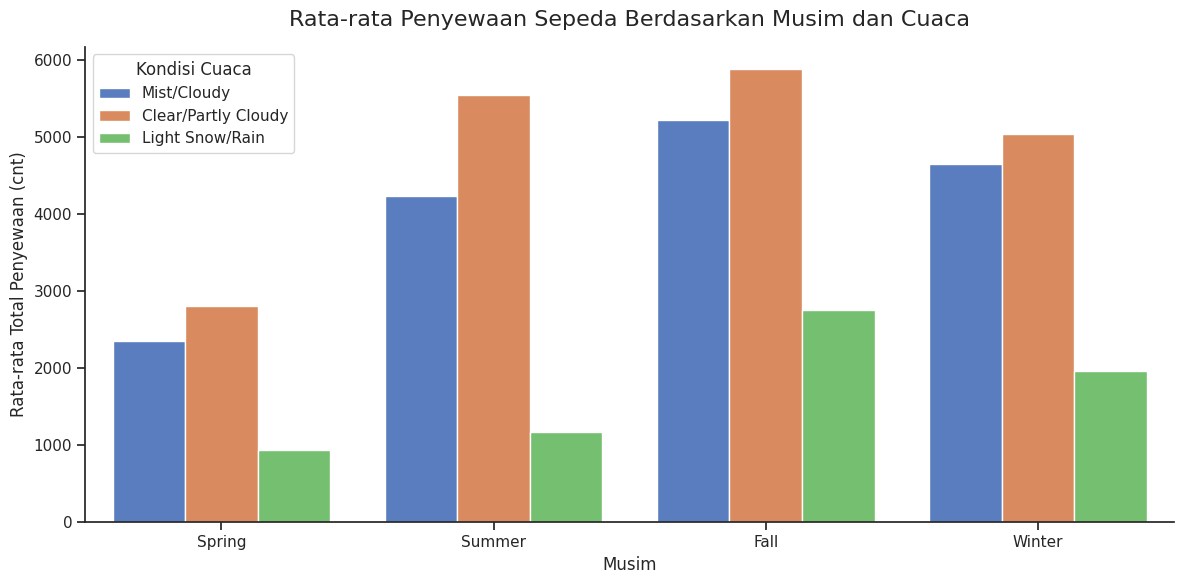

In [8]:
plt.figure(figsize=(12, 6))

# Menggunakan barplot untuk membandingkan rata-rata penyewaan
ax = sns.barplot(
    x='season_label',
    y='cnt',
    hue='weather_label',
    data=day_df,
    errorbar=None,
    palette='muted'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Musim dan Cuaca', fontsize=16, pad=15)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Rata-rata Total Penyewaan (cnt)', fontsize=12)
plt.legend(title='Kondisi Cuaca')

# Meningkatkan Data-Ink Ratio dengan menghilangkan spine atas dan kanan
sns.despine()

# Menjaga baseline sumbu Y dimulai dari 0 untuk menghindari Lie Factor yang menipu
ax.set_ylim(ymin=0)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana pola penyewaan sepeda berdasarkan jam dalam sehari antara hari kerja dan hari libur?

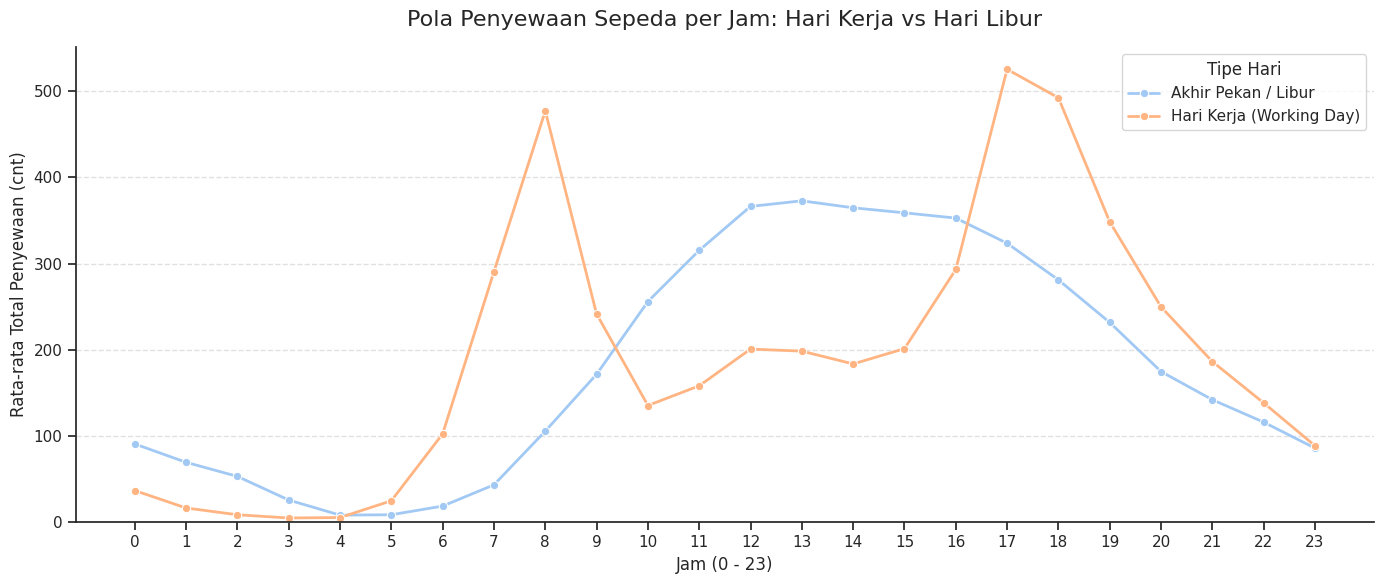

In [9]:
plt.figure(figsize=(14, 6))

# Mengubah label workingday untuk legend
hour_df['day_type'] = hour_df['workingday'].map({1: 'Hari Kerja (Working Day)', 0: 'Akhir Pekan / Libur'})

# Membuat line chart
ax2 = sns.lineplot(
    x='hr',
    y='cnt',
    hue='day_type',
    data=hour_df,
    marker='o',
    errorbar=None,
    linewidth=2
)

plt.title('Pola Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur', fontsize=16, pad=15)
plt.xlabel('Jam (0 - 23)', fontsize=12)
plt.ylabel('Rata-rata Total Penyewaan (cnt)', fontsize=12)
plt.xticks(np.arange(0, 24, 1)) # Memastikan semua jam tampil di sumbu X
plt.legend(title='Tipe Hari')
plt.grid(axis='y', linestyle='--', alpha=0.6) # Grid horizontal ringan

# Optimasi Data-Ink Ratio
sns.despine()
ax2.set_ylim(ymin=0)

plt.tight_layout()
plt.show()

**Insight Visualisasi:**
- **Visualisasi 1:** Cuaca cerah mendominasi tingginya angka penyewaan di seluruh musim. Cuaca ekstrem (hujan lebat/salju) mematikan minat penyewaan hampir secara keseluruhan. Cuaca, curah hujan, dan musim memang sangat mempengaruhi perilaku rental.
- **Visualisasi 2:** Terlihat lonjakan ekstrem (bimodal peak) pada pukul 08:00 dan 17:00 di hari kerja, mengindikasikan sepeda digunakan untuk transportasi commuting kantoran. Di akhir pekan, polanya memusat membentuk kurva lonceng di siang hari antara jam 10:00 hingga 16:00.

## Analisis Lanjutan (Opsional): Clustering/Binning Waktu Dalam Sehari

Kita akan menerapkan teknik Manual Grouping (Binning) tanpa Machine Learning untuk mengelompokkan jam ke dalam kategori waktu (Pagi, Siang, Sore, Malam) dan melihat perilaku pengguna kasual (casual) vs pengguna terdaftar (registered).

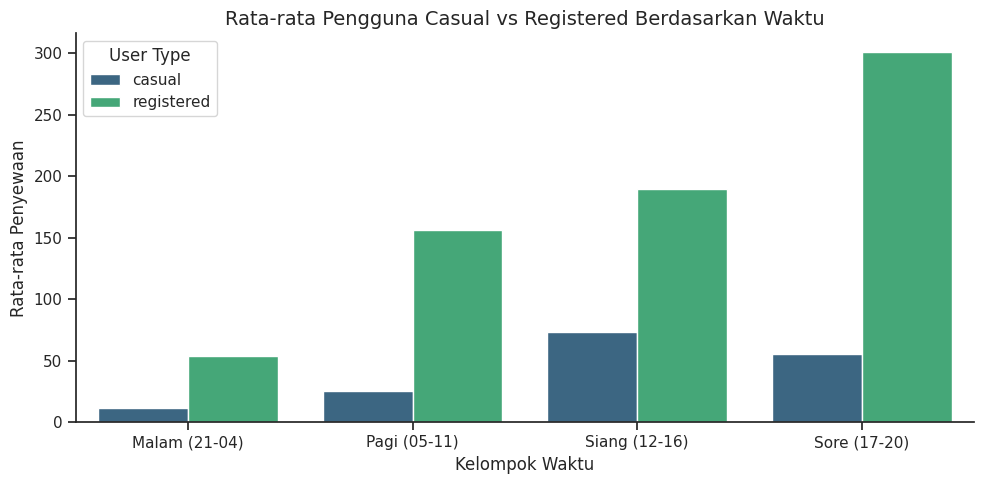

In [10]:
# Mendefinisikan fungsi binning waktu
def categorize_time_of_day(hour):
    if 5 <= hour <= 11:
        return 'Pagi (05-11)'
    elif 12 <= hour <= 16:
        return 'Siang (12-16)'
    elif 17 <= hour <= 20:
        return 'Sore (17-20)'
    else:
        return 'Malam (21-04)'

# Menerapkan fungsi ke dataset
hour_df['time_group'] = hour_df['hr'].apply(categorize_time_of_day)

# Agregasi data pengguna casual vs registered berdasarkan kelompok waktu
time_clustering = hour_df.groupby('time_group')[['casual', 'registered']].mean().reset_index()

# Visualisasi hasil grouping
time_clustering_melted = time_clustering.melt(id_vars='time_group', var_name='User Type', value_name='Average Rentals')

plt.figure(figsize=(10, 5))
ax3 = sns.barplot(x='time_group', y='Average Rentals', hue='User Type', data=time_clustering_melted, palette='viridis')
plt.title('Rata-rata Pengguna Casual vs Registered Berdasarkan Waktu', fontsize=14)
plt.xlabel('Kelompok Waktu', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)

# Optimasi Integritas Visual
sns.despine()
ax3.set_ylim(ymin=0)
plt.tight_layout()
plt.show()

**Insight Analisis Lanjutan:**
- Melalui binning berbasis aturan waktu operasional, dapat disimpulkan bahwa kelompok pengguna registered sangat mendominasi penyewaan secara absolut, khususnya pada sesi Sore (17:00-20:00) saat jam pulang kerja. Pengguna casual paling aktif di waktu Siang (12:00-16:00), kemungkinan besar merupakan turis atau penyewa rekreasi santai.

## Conclusion

- **Conclution pertanyaan 1 :** Kondisi iklim memiliki korelasi langsung dan signfikan terhadap operasional sistem. Pengguna lebih banyak menyewa sepeda di musim gugur (Fall) dan musim panas (Summer) yang udaranya mendukung, dibandingkan musim dingin. Cuaca yang cerah/berawan terbukti menjadi faktor krusial yang mendorong naiknya total penyewaan, sementara cuaca hujan badai nyaris menghentikan angka rental harian sepenuhnya.
- **Conclution pertanyaan 2 :** Perilaku demografi pengguna sangat terbagi berdasarkan hari. Pada hari kerja, pola penggunaan membuktikan bahwa sepeda dipakai sebagai alat komuter dengan lonjakan tajam pada pagi hari (08:00) dan sore hari (17:00). Sebaliknya, pada akhir pekan atau hari libur, waktu sewa tersebar merata sebagai sarana rekreasi siang hari di antara rentang waktu pukul 10:00 hingga pukul 16:00 tanpa adanya spike komuter. Waktu jam tertentu sangat berpengaruh terhadap fluktuasi data.

In [13]:
# Menggabungkan dataset hour_df dan day_df menjadi all_df
# Kita menggunakan left join berdasarkan kolom tanggal 'dteday'
# Suffixes digunakan untuk membedakan nama kolom yang sama antara kedua dataset (contoh: cnt_hour dan cnt_day)
all_df = pd.merge(
    left=hour_df,
    right=day_df,
    how="left",
    left_on="dteday",
    right_on="dteday",
    suffixes=("_hour", "_day")
)

# Melihat sekilas gabungan datanya
display(all_df.head())

# Menyimpan dataframe all_df menjadi file main_data.csv
all_df.to_csv("main_data.csv", index=False)

print("Berhasil! File main_data.csv telah dibuat.")

,instant_hour,dteday,season_hour,yr_hour,mnth_hour,hr,holiday_hour,weekday_hour,workingday_hour,weathersit_hour,...,weathersit_day,temp_day,atemp_day,hum_day,windspeed_day,casual_day,registered_day,cnt_day,season_label_day,weather_label_day
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Mist/Cloudy
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Mist/Cloudy
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Mist/Cloudy
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Mist/Cloudy
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Mist/Cloudy


Berhasil! File main_data.csv telah dibuat.
